<a href="https://colab.research.google.com/github/Murad114370/my_first_app/blob/main/Crack_Image_Classification_using_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
train_path = "/content/drive/MyDrive/Dataset/train"
valid_path = "/content/drive/MyDrive/Dataset/valid"
test_path  = "/content/drive/MyDrive/Dataset/test"


In [4]:
import os
print("Train Crack: ",len(os.listdir(train_path + "/Crack")))
print("Train Smooth: ",len(os.listdir(train_path + "/Smooth")))

print("Valid Crack: ",len(os.listdir(valid_path + "/Crack")))
print("Valid Smooth: ",len(os.listdir(valid_path + "/Smooth")))

print("Test Crack: ",len(os.listdir(test_path + "/Crack")))
print("Test Smooth: ",len(os.listdir(test_path + "/Smooth")))

Train Crack:  5001
Train Smooth:  5001
Valid Crack:  1900
Valid Smooth:  1999
Test Crack:  1999
Test Smooth:  2000


In [5]:
print("Train",os.listdir(train_path))
print("Valid",os.listdir(valid_path))
print("Test",os.listdir(test_path))

Train ['Smooth', 'Crack']
Valid ['Smooth', 'Crack']
Test ['Smooth', 'Crack']


In [6]:
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')

In [7]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
datagen = ImageDataGenerator(rescale=1./255)

In [8]:
train_data = datagen.flow_from_directory(
    train_path,
    target_size=(128, 128),
    batch_size=64,
    class_mode='binary'
)

Found 10002 images belonging to 2 classes.


In [9]:
valid_data = datagen.flow_from_directory(
    valid_path,
    target_size=(128, 128),
    batch_size=64,
    class_mode='binary'
)

Found 3899 images belonging to 2 classes.


In [10]:
test_data = datagen.flow_from_directory(
    test_path,
    target_size=(128, 128),
    batch_size=64,
    class_mode='binary',
    shuffle=False
)

Found 3999 images belonging to 2 classes.


In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [12]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(256, activation='relu'),
    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,516,289 (24.86 MB)

 Trainable params: 6,516,289 (24.86 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [15]:
history = model.fit(
    train_data,
    epochs=10,
    validation_data=valid_data
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 4290s 27s/step - accuracy: 0.8588 - loss: 0.3534 - val_accuracy: 0.0203 - val_loss: 8.8320
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 50s 321ms/step - accuracy: 0.9859 - loss: 0.0512 - val_accuracy: 0.0141 - val_loss: 10.2542
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 50s 318ms/step - accuracy: 0.9895 - loss: 0.0464 - val_accuracy: 0.0128 - val_loss: 9.6712
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 51s 326ms/step - accuracy: 0.9905 - loss: 0.0471 - val_accuracy: 0.0369 - val_loss: 14.9026
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 51s 326ms/step - accuracy: 0.9860 - loss: 0.0536 - val_accuracy: 0.0310 - val_loss: 9.4033
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 50s 321ms/step - accuracy: 0.9939 - loss: 0.0209 - val_accuracy: 0.0187 - val_loss: 10.0842
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 51s 323ms/step - accuracy: 0.9952 - loss: 0.0174 - val_accuracy: 0.0282 - val_loss: 12.5524
Epoch 8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 50s 320ms/step - accuracy: 0.9905 - los

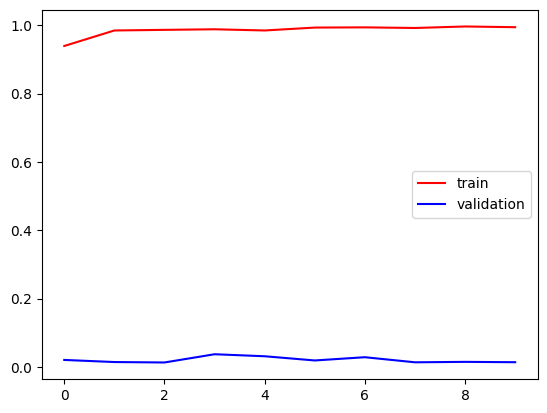

In [17]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

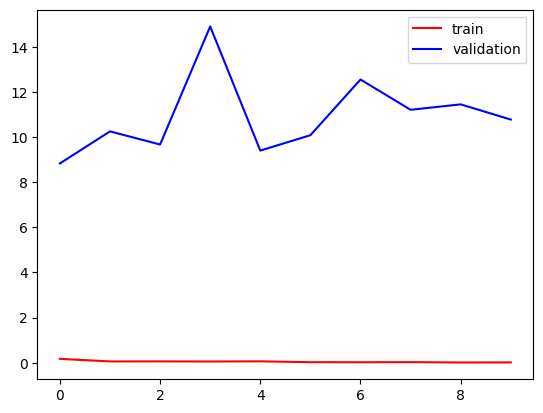

In [20]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()

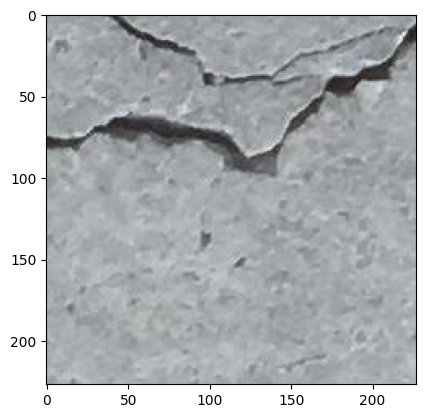

In [23]:
import cv2
test_img = cv2.imread('/content/drive/MyDrive/Dataset/test/Crack/18882_1.jpg')
plt.imshow(test_img)

In [24]:
test_img.shape

(227, 227, 3)

In [25]:
test_img = cv2.resize(test_img,(128,128))

In [26]:
test_input = test_img.reshape((1,128,128,3))

In [27]:
model.predict(test_input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 839ms/step


array([[1.]], dtype=float16)

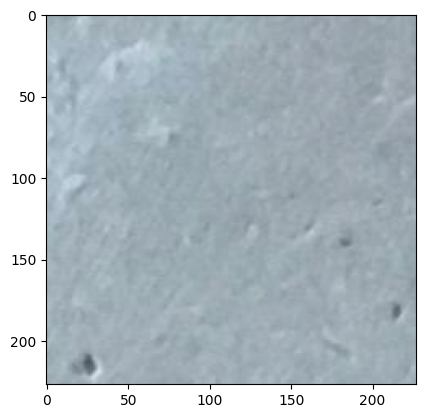

In [31]:
test_img1 = cv2.imread('/content/drive/MyDrive/Dataset/test/Smooth/18208.jpg')
plt.imshow(test_img1)

In [32]:
test_img1.shape


(227, 227, 3)

In [36]:
test_img1 = cv2.resize(test_img1,(128,128))

In [38]:
test_input1 = test_img1.reshape((1,128,128,3))

In [39]:
model.predict(test_input1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


array([[0.]], dtype=float16)